In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("heart_disease_uci.csv")

In [107]:
print(df.head(3))
print("Shape:")
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())


   id  age   sex    dataset              cp  trestbps   chol    fbs  \
0   1   63  Male  Cleveland  typical angina     145.0  233.0   True   
1   2   67  Male  Cleveland    asymptomatic     160.0  286.0  False   
2   3   67  Male  Cleveland    asymptomatic     120.0  229.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  
Shape:
(920, 16)

Missing Values:
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

Duplicate Rows:
0


In [108]:
# Drop columns with huge missing values
df = df.drop(columns=['ca', 'thal'])

# Fill numerical missing values
num_cols = ['trestbps','chol','thalch','oldpeak']

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical missing values
cat_cols = ['fbs','exang','restecg','slope']

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


In [ ]:
#df = df.drop(columns=['ca', 'thal'])
# drops ca and thal cause it has too many missing values and if u fill them u will be guessing half of the data
#numerical values-200, 210, NaN, 220, 600
#median ≈ 215 so Nan becomes 215
#categorical values
#slope
#flat
#upsloping
#NaN
#flat
#flat
-----
#slope
#flat
#upsloping
#flat
#flat
#flat
#Nan is replaced with the most frequent label

In [109]:
print("\nMissing Values After Cleaning:")
print(df.isnull().sum())


Missing Values After Cleaning:
id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
num         0
dtype: int64


In [110]:
from sklearn.preprocessing import LabelEncoder

for col in ['sex','dataset','cp','restecg','slope']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

In [111]:
print(df.dtypes)

id            int64
age           int64
sex           int32
dataset       int32
cp            int32
trestbps    float64
chol        float64
fbs          object
restecg       int32
thalch      float64
exang        object
oldpeak     float64
slope         int32
num           int64
dtype: object


In [112]:
df = df.drop('id', axis=1)
corr_target = df.corr()['num'].abs()

top_features = corr_target.sort_values(
    ascending=False
)

print(top_features.head(10))


num        1.000000
oldpeak    0.411588
exang      0.350567
thalch     0.349173
age        0.339596
cp         0.314518
dataset    0.276203
sex        0.259342
chol       0.230539
slope      0.201875
Name: num, dtype: float64


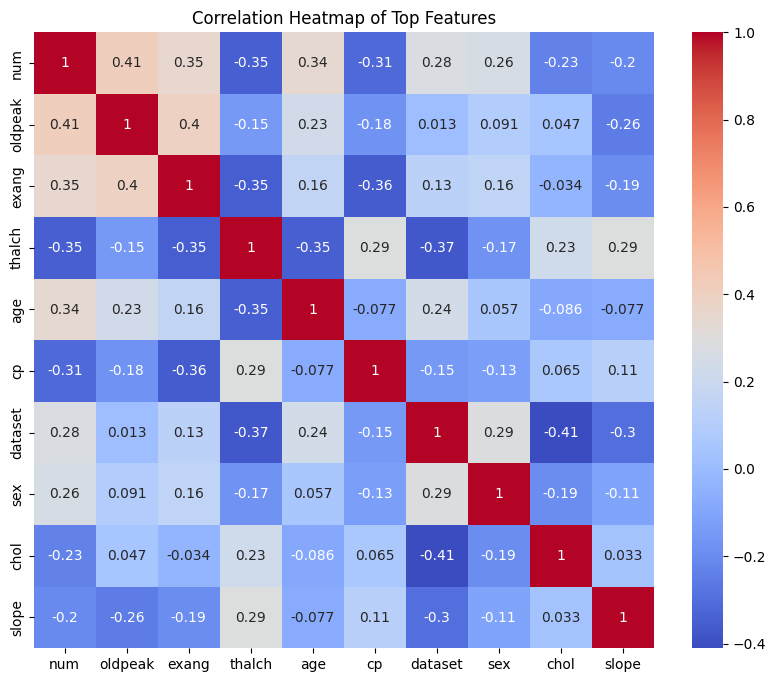

In [113]:
corr_target = df.corr()['num'].abs()

top_features = corr_target.sort_values(
    ascending=False
)

important_features = top_features.head(10).index

plt.figure(figsize=(10,8))

sns.heatmap(
    df[important_features].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap of Top Features")
plt.show()

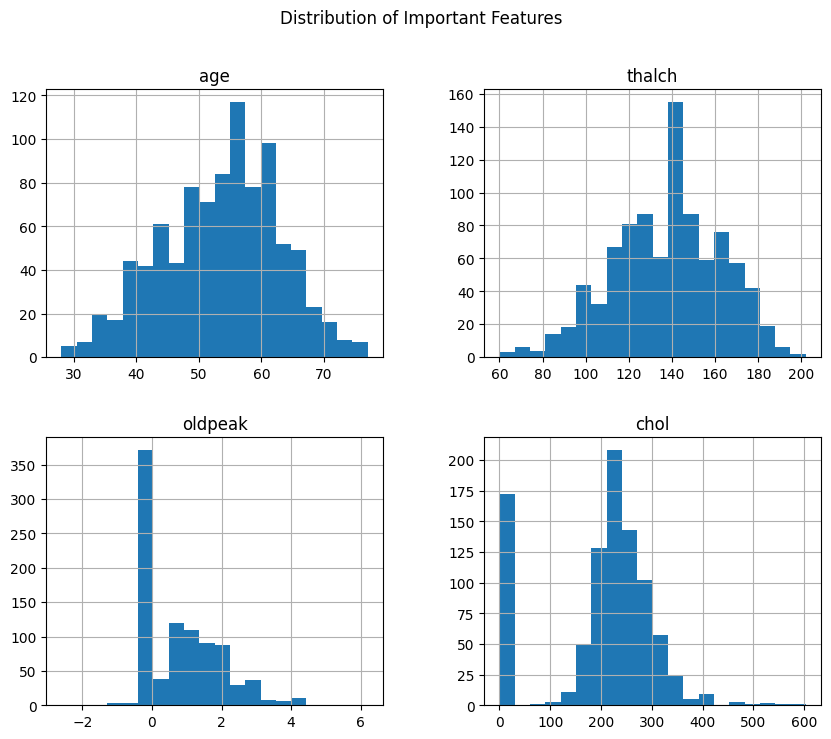

In [114]:
df[['age','thalch','oldpeak','chol']].hist(
    bins=20,
    figsize=(10,8)
)

plt.suptitle("Distribution of Important Features")
plt.show()

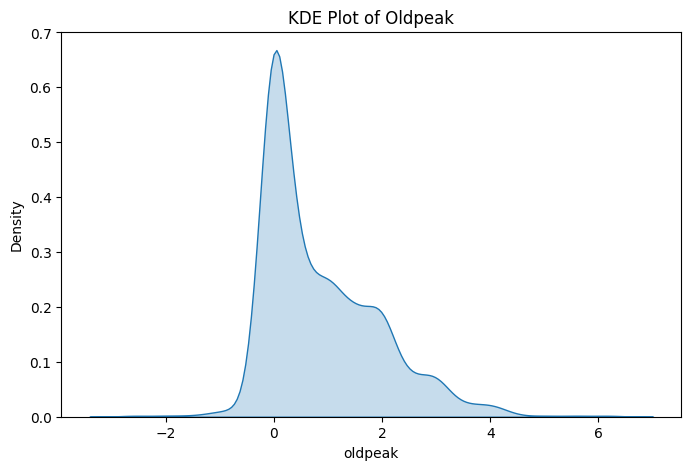

In [115]:
plt.figure(figsize=(8,5))

sns.kdeplot(
    df['oldpeak'],
    fill=True
)

plt.title("KDE Plot of Oldpeak")
plt.show()

In [116]:
Q1 = df['oldpeak'].quantile(0.25)
Q3 = df['oldpeak'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

outliers = df[
    (df['oldpeak'] < lower) |
    (df['oldpeak'] > upper)
]

print("Outliers:", len(outliers))

Outliers: 16


In [ ]:
#1, 2, 3, 4, 5, 6, 7, 100
#LF 1, 2, 3, 4
#Q1 = (2 + 3) / 2
#    = 2.5
#UF 5, 6, 7, 100
#Q3 = (6 + 7) / 2
#    = 6.5
#IQR = Q3 - Q1
#     = 6.5 - 2.5
#     = 4
#Lower bound Q1 - 1.5 × IQR
#= 2.5 - 1.5 × 4
#= 2.5 - 6
#= -3.5
#Upper bound
#Q3 + 1.5 × IQR
#= 6.5 + 6
#= 12.5
#< -3.5
#or
#> 12.5 is an outlier

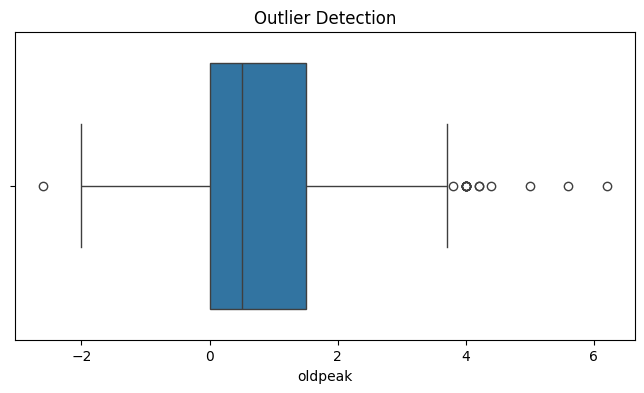

In [117]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df['oldpeak'])

plt.title("Outlier Detection")
plt.show()

In [118]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = df.drop('num', axis=1)
y = df['num']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(
    ascending=False
)

print(importance.head(10))

thalch      0.141164
age         0.137667
chol        0.128245
oldpeak     0.122520
trestbps    0.111286
cp          0.085501
dataset     0.077022
exang       0.056827
restecg     0.046154
slope       0.038164
dtype: float64


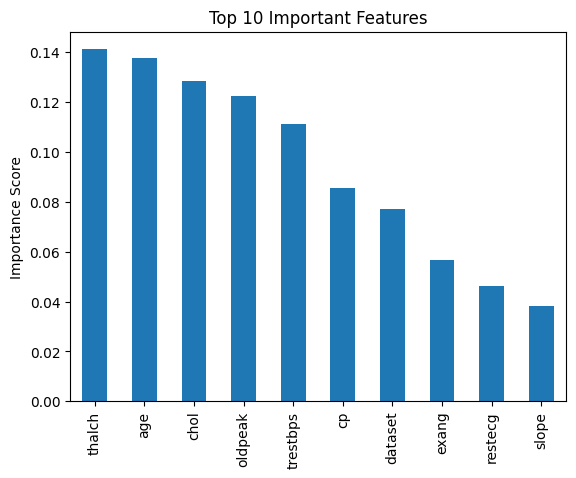

In [119]:
importance.head(10).plot(kind='bar')

plt.title("Top 10 Important Features")
plt.ylabel("Importance Score")

plt.show()

In [120]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = df.drop('num', axis=1)

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print(pca.explained_variance_ratio_)
print(sum(pca.explained_variance_ratio_))

[0.22483806 0.13850392]
0.3633419747780613
